# Natural Language Processing

Questo campo include tutte le task dove l'IA prende la lingua umana come input.

# Sintassi e Semantica

## Sintassi

La sintassi è la struttura di una frase.

In quanto madrelingua, non fatichiamo a produrre frasi grammaticalmente corrette e a notare quelle sbagliate. La sintassi può essere grammaticalmente giusta e ambigua allo stesso tempo, ad esempio "Ho visto un uomo col telescopio". L'uomo aveva il telescopio oppure ho usato un telescopio per vederlo?

Per essere in grado di valutare la lingua umana, le IA devono padroneggiare la sintassi.

## Semantica

La semantica è il significato di parole e frasi. Due frasi possono essere sintatticamente diverse ma semanticamente uguali.

Inoltre, alcune frasi possono essere sintatticamente e grammaticalmente corrette, ma essere completamente insensate. Esempio di Chomsky:  “Colorless green ideas sleep furiously.”

Per essere in grado di valutare la lingua umana, le IA devono padroneggiare la semantica.

# Context-Free Grammar

La grammatica formale è un sistema di regole per generare frasi in una lingua.

Nella grammatica senza contesto, il testo è astratto dal suo significato per rappresentare la struttura della frase usando la grammatica formale.

Consideriamo la seguente frase:

- She saw the city.

Iniziamo assegnando a ogni parola il suo ruolo nel linguaggio:
* **She** e **city** sono pronomi, che marcheremo come `N`.
* **Saw** è un verbo, che marcheremo come `V`.
* **The** è l'articolo determinativo, che marchiano i pronomi come definiti o indefiniti. Lo indicheremo con `D`

Ora, la frase può essere riscritta come:

- N V D N

Finora, abbiamo estratto ogni parola dal suo significato semantico al suo ruolo nel linguaggio. Tuttavia, le parole in una frase sono interconnesse, e per capire una frase dobbiamo capire in che modo si connettono.

Una frase pronome (NP) è un gurppo di parole che si connettono a un pronome. Ad esempio:
- La parole *she* nell'esempio sopra è una frase pronome.

Una frase verbo (VP) è un gruppo di parole che si connettono a un verbo.
- La parola *saw* è una frase verbo già se presa da sola.

Tuttavia, anche le parole *saw the city* creano una frase verbo. In questo caso si tratta diuna frase verbo che consiste di un verbo e una frase pronome, che a sua volta consiste in un articolo e un pronome.

Detto questo, possiamo rappresentare tutta la frase **S** come segue:

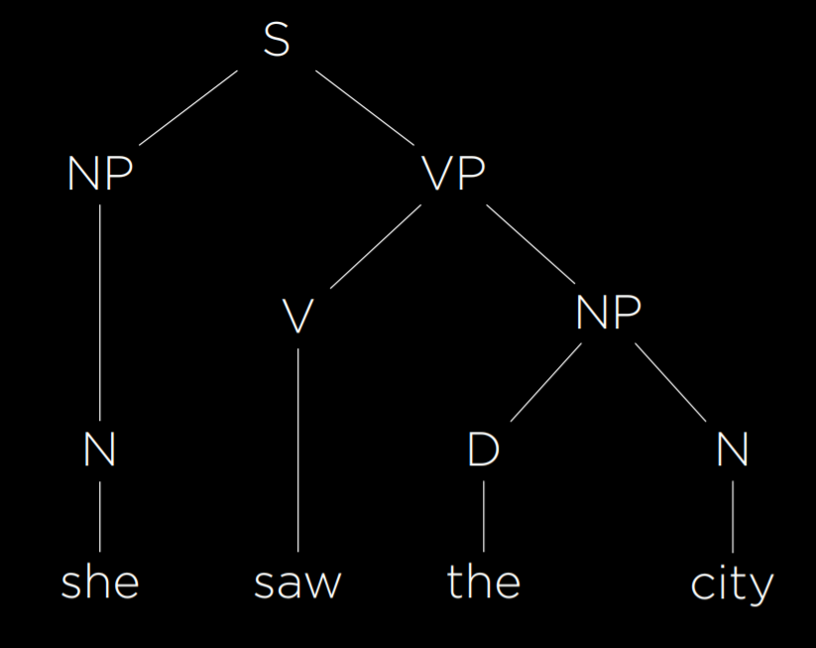

Usando la grammatica formale, l'IA è in grado di rappresentare la struttura delle frasi. Nella grammatica che abbiamo descritto, ci sono abbastanza regole per rappresentare la frase semplice scritta sopra.

Per rappresentare frasi più complesse, dobbiamo aggiungere più regole alla nostra grammatica formale.

# nltk

**nltk** (Natural Language ToolKit) è una libreria per implementare l'idea sopracitata.

Il codice non può essere eseguito in jupyter ma si trova in: [cfg0.py](cfg\cfg0.py) oppure [cfg1.py](cfg\cfg1.py)

Per analizzare la sentence, provvediamo l'algoritmo con regole per la grammatica:

In [1]:
import nltk

grammar = nltk.CFG.fromstring("""
    S -> NP VP

    NP -> D N | N
    VP -> V | V NP

    D -> "the" | "a"
    N -> "she" | "city" | "car"
    V -> "saw" | "walked"
""")

parser = nltk.ChartParser(grammar)

Similmente a come fatto sopra, definiamo quali possibili componenti possono essere inclusi in altri.

Una sentence può includere una frase pronome e una frase verbo, mentre le frasi stesse consistono di altre frasi, pronomi, verbi, etc... e, infine, ogni parte del linguaggio include alcune parole della lingua.

In [ ]:
sentence = input("Sentence: ").split()
try:
    for tree in parser.parse(sentence):
        tree.pretty_print()
        tree.draw()
except ValueError:
    print("No parse tree possible.")

No parse tree possible.


Dopo aver dato all'algoritmo una sentence di input divisa in una lista di parole, la funzione mostra l'albero sintattico risultante (pretty_print) e genera una rappresentazione grafica (draw).

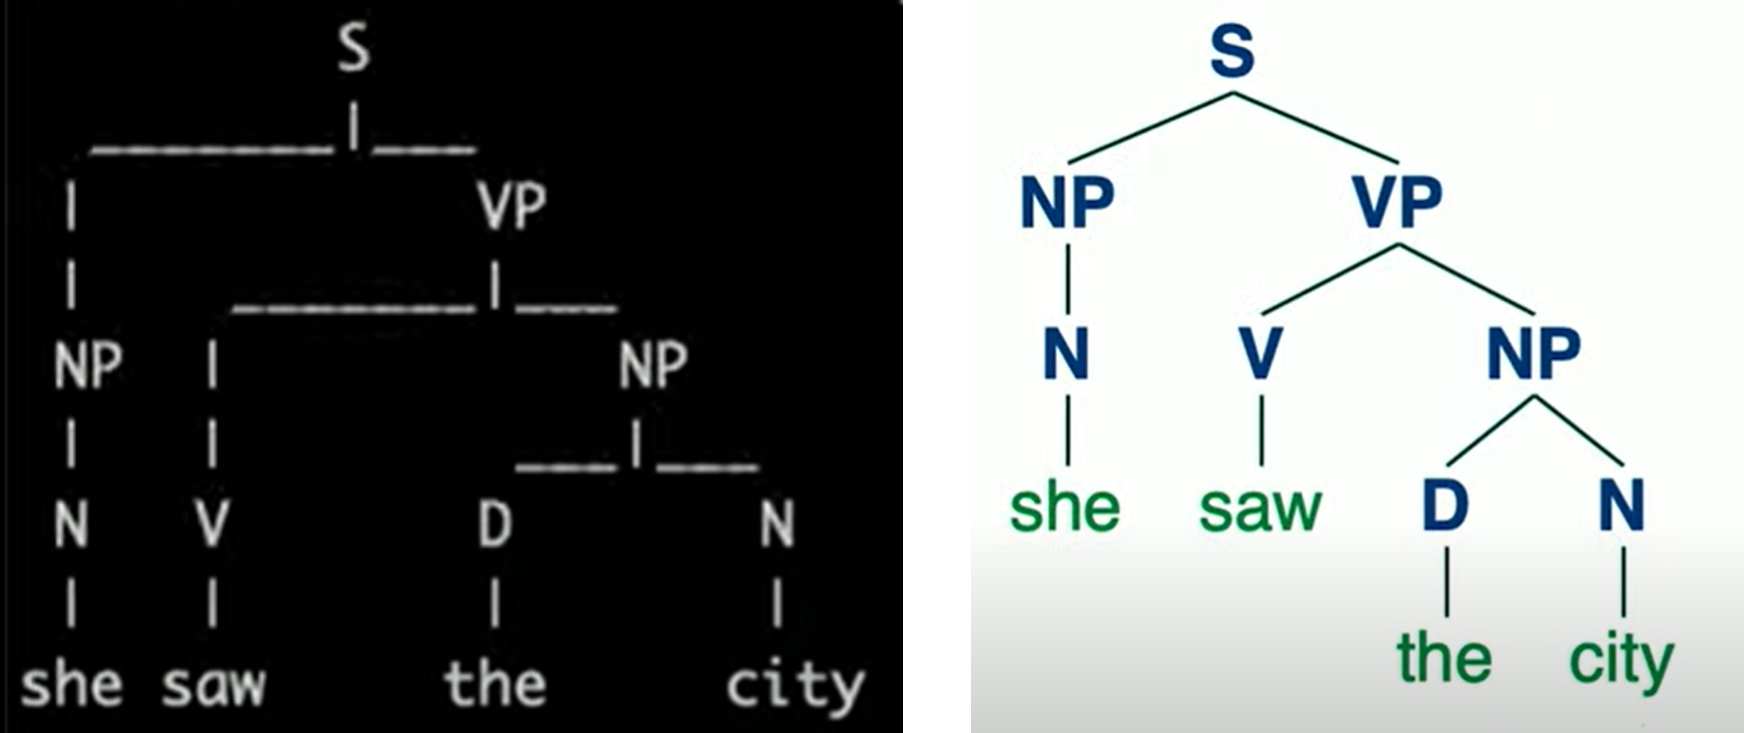

# n-grams

Un *n-gram* è una sequenza di $n$ oggetti da un campione di testo.

In un **carattere $n$-gram** gli oggetti sono caratteri, e in un **word $n$-gram** gli oggetti sono parole.

Un *unigram*, *bigram* e *trigram* sono sequenze di uno, due e tre oggetti. Nella sentence seguente, i primi tre $n$-gram sono "how often have", "often have I" e "have I said":

“How often have I said to you that when you have eliminated the impossible whatever remains, however improbable, must be the truth?”

Gli $n$-gram sono utili per processare testo. Anche se l'IA non ha necessariamente visto tutta la sentence prima, sicuramente ha visto parti di essa, come "have I said". Dal momento che alcune parole si presentano insieme più spesso di altre, è possibile anche predirre la prossima parola con una certa probabilità. Quindi, un buon passo da fare nel language processing è separare la sentence in $n$-gram.

# Tokenization

Tokenization è la task di spezzare una sequenza di caratteri in pezzi (token). I token possono essere sia parole che sentence, nel qual caso la task si chiama **word tokenization** o **sentence tokenization**. Abbiamo bisogno della tokenization per essere in grado di valutare gli $n$-gram, dal momento che questi si basano su sequenze di token.

Iniziamo separando il testo in parole basandoci sullo spazio tra i caratteri. Anche se questo è un buon inizio, è imperfetto perché finiremo con l'avere parole con punteggiatura, come "remains,". Possiamo quindi rimuovere la punteggiatura.

Avremo però altre sfide, come parole che hanno apostrofi (o'clock) e trattini (pearl-grey). Inoltre, alcuni simboli di punteggiatura sono importanti per la struttura delle frasi, come i punti. Dobbiamo quindi essere in grado di differenziare tra un punto alla fine di una frase e uno in una parola come "Mr.".

Avere a che fare con questi problemi è il processo della tokenizzazione. Alla fine, una volta che abbiamo i nostri token, possiamo guardare agli $n$-gram.

# Modelli di Markov

Come discusso nelle lezioni precedenti, i modello di Markov consistono in nodi, e il valore di ogni nodo ha una distribuzione probabilistica basata su un numero finito di nodi precedenti.

I modelli di Markov possono essere usati per generare testo. Per fare ciò, alleniamo il modello su un testo, poi stabiliamo probabilità per ogni token $n$-esimo in un $n$-gram basato sulle $n$ parole che lo precedono.

Ad esempio, usando i trigram, dopo che il modello di Markov ha due parole può sceglierne una terza da una distribuzione di probabilità basata sulle prime due. Poi può sceglierne una quarta da una distribuzione di probabilità basata sulla seconda e terza parola.

Per vedere un'implementazione di un modello simile usando `nltk`, fare riferimento a [generator.py](markov/generator.py). Qui il modello impara a generare sentence che assomigliano a quelle di Shakespeare.

Eventualmente, usando i modelli di Markov, siamo in grado di generare testo che è spesso grammatico e suona superficialmente simile alla lingua umana. Tuttavia, queste frasi mancano di significato.

# Modello Bag-of-Words

Bag-of-words è un modello che rappresenta il testo come una collezione non ordinata di parole. Questo modello ignora la sintassi e considera solo il significato delle parole nella frase. Questo approccio è utile in alcuni compiti di classificazione, come sentiment analysis (un altro compito di classificazione sarebbe distinguere una "regular email" da una "spam email"). La sentiment analysis può essere usata, per esempio, nelle recensioni di prodotti, categorizzando le recensioni come positive o negative. Considera le seguenti frasi:

1. “My grandson loved it! So much fun!”
2. “Product broke after a few days.”
3. “One of the best games I’ve played in a long time.”
4. “Kind of cheap and flimsy, not worth it.”

Basandoci solo sulle parole in ciascuna frase e ignorando la grammatica, possiamo vedere che le frasi 1 e 3 sono positive (“loved,” “fun,” “best”) e le frasi 2 e 4 sono negative (“broke,” “cheap,” “flimsy”).

# Naive Bayes

Naive Bayes è una tecnica che può essere usata per la sentiment analysis col modello bag-of-words. Nella sentiment analysis stiamo chiedendo "Quale è la probabilità che la frase è positiva/negativa date le parole al suo interno."

Rispondere a questa domanda richiede calcolare la probabilità condizionata, ed è utile ricordare la regola di Bayes dalla lezione 2:

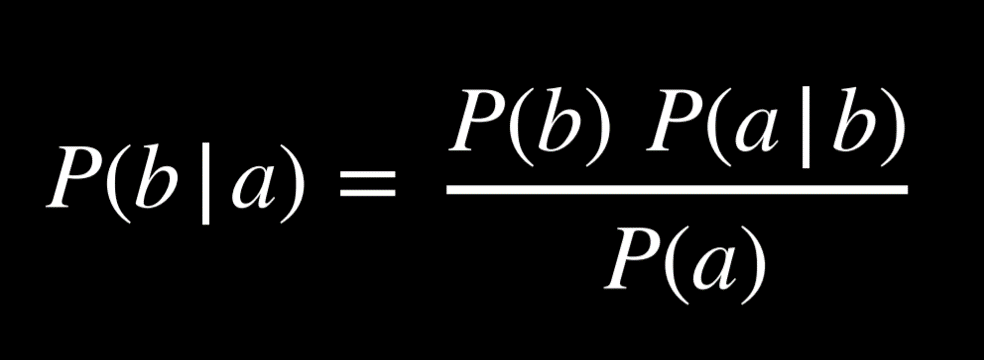

Ora vogliamo usare questa formula per trovare $P(sentiment \mid text)$, o, per esempio, $P(positive \mid "my\ grandson\ loved\ it")$.

* Iniziamo tokenizzando l’input, in modo da ottenere $P(positive \mid "my",\ "grandson",\ "loved",\ "it")$.
* Applicando direttamente la regola di Bayes, otteniamo la seguente espressione:
  * $P("my",\ "grandson",\ "loved",\ "it" \mid positive) \cdot P(positive) / P("my",\ "grandson",\ "loved",\ "it")$.

Quest'espressione ci darà la risposta precisa a $P(positive \mid "my", "grandson", "loved", "it")$.

Tuttavia, possiamo semplificare l’espressione se siamo disposti ad accettare una risposta che non è uguale, ma proporzionale, a $P(positive \mid "my",\ "grandson",\ "loved",\ "it")$.

In seguito, sapendo che la distribuzione di probabilità deve sommare a 1, possiamo normalizzare il valore ottenuto per ottenere una probabilità esatta. Questo significa che possiamo semplificare l’espressione precedente considerando solo il numeratore:

$P("my",\ "grandson",\ "loved",\ "it" \mid positive) \cdot P(positive)$.

Di nuovo, possiamo semplificare quest’espressione basandoci sulla conoscenza che una probabilità condizionata di $a$ dato $b$ è proporzionale alla probabilità congiunta di $a$ e $b$. Otteniamo quindi la seguente espressione per la nostra probabilità:

$P(positive,\ "my",\ "grandson",\ "loved",\ "it") \cdot P(positive)$.

Calcolare questa probabilità congiunta, tuttavia, è complicato perché la probabilità di ogni parola è condizionata dalle probabilità delle parole precedenti. Richiede infatti di calcolare:
$P(positive) \cdot P("my" \mid positive) \cdot P("grandson" \mid positive, "my") \cdot P("loved" \mid positive, "my", "grandson") \cdot P("it" \mid positive, "my", "grandson", "loved")$.
___
È qui che usiamo la regola di Bayes in modo *naive* (ingenuo): assumiamo che la probabilità di ogni parola sia indipendente dalle altre. Questo non è vero, ma nonostante questa imprecisione, Naive Bayes produce una buona stima del sentiment. Usando questa assunzione, otteniamo la seguente probabilità:

$P(positive) \cdot P("my" \mid positive) \cdot P("grandson" \mid positive) \cdot P("loved" \mid positive) \cdot P("it" \mid positive)$

che non è troppo difficile da calcolare.

* $P(positive)$ = numero di tutti i campioni positivi diviso per il numero totale di campioni.
* $P("loved" \mid positive)$ è uguale al numero di campioni positivi contenenti la parola "loved" diviso per il numero di campioni positivi.

Consideriamo l’esempio qui sotto, con emoji sorridenti e tristi al posto delle parole “positive” e “negative”:

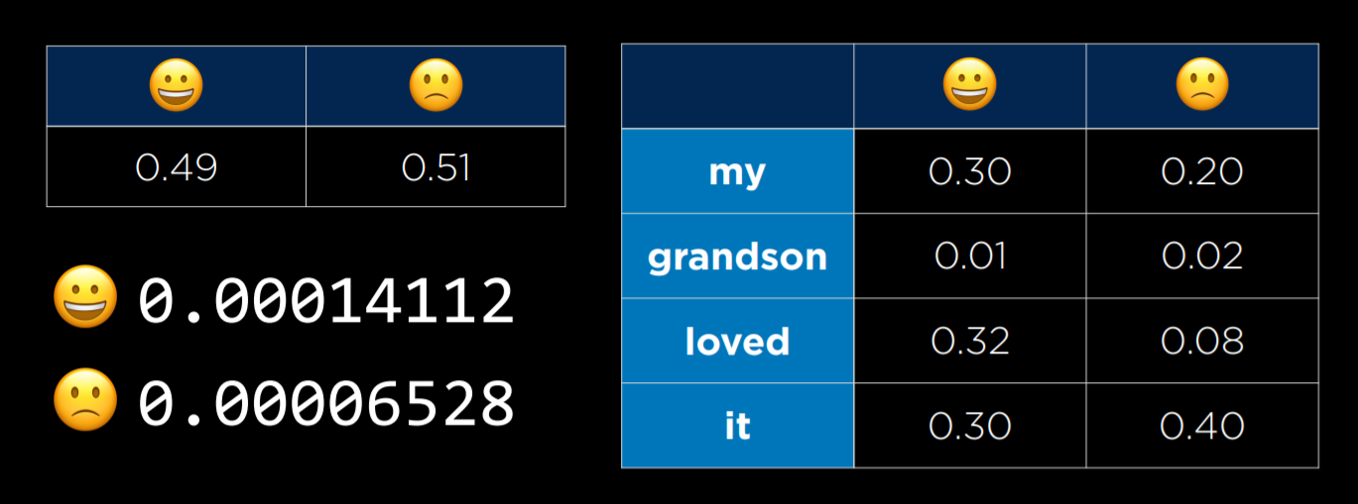

- A destra vediamo una tabella con le probabilità condizionate di ciascuna parola (sulla sinistra) che appare in una frase, dato che la frase sia positive o negative.
- Nella piccola tabella a sinistra vediamo la probabilità che una frase sia positive o negative.
- In basso a sinistra vediamo le probabilità risultanti dopo il calcolo. A questo punto, sono proporzionali tra loro, ma non ci dicono molto in termini di probabilità effettive.

Per ottenere le probabilità vere e proprie, dobbiamo normalizzare i valori, arrivando a:

$P(positive) = 0.6837$ e $P(negative) = 0.3163$.

La forza del Naive Bayes sta nel fatto che è sensibile alle parole che compaiono più frequentemente in un tipo di frase rispetto all’altro. Nel nostro caso, la parola “loved” compare molto più spesso nelle frasi positive, il che rende l’intera frase più probabile essere positive piuttosto che negative.

Per vedere un’implementazione della valutazione del sentiment usando Naive Bayes con la libreria nltk, fai riferimento al file [sentiment.py](sentiment/sentiment.py).
___

Un problema che possiamo incontrare è che alcune parole potrebbero non comparire mai in un certo tipo di frase. Supponiamo che nessuna delle frasi *positive* nel nostro campione contenga la parola “grandson.” In tal caso, $P("grandson" \mid positive) = 0$, e quando calcoliamo la probabilità che la frase sia *positive* otterremo 0. Tuttavia, questo non riflette la realtà (non tutte le frasi che menzionano “grandson” sono *negative*).

Un modo per affrontare questo problema è tramite l'**Additive Smoothing**, dove aggiungiamo un valore $\alpha$ a ciascun valore nella nostra distribuzione per rendere i dati più “morbidi”. In questo modo, anche se un certo valore è 0, aggiungendo $\alpha$ evitiamo di moltiplicare l’intera probabilità della frase *positive* o *negative* per 0.

Un tipo specifico di additive smoothing, chiamato **Laplace Smoothing** e consiste nell’aggiungere 1 a ciascun valore nella distribuzione, fingendo che tutti i valori siano stati osservati almeno una volta.

# Word Representation

Vogliamo rappresentare il significato delle parole nella nostra IA. Come abbiamo visto in precedenza, è comodo fornire input all'IA sotto forma di numeri. Un modo per farlo è usare la **One-Hot Representation**, in cui ogni parola è rappresentata da un vettore che ha tanti valori quante sono le parole.

Tranne un singolo valore pari a 1, tutti gli altri sono 0. Possiamo distinguere le parole in base alla posizione del valore pari a 1, ottenendo così un vettore unico per ogni parola.

Per esempio, la frase “He wrote a book” può essere rappresentata da quattro vettori:

```
[1, 0, 0, 0] (he)  
[0, 1, 0, 0] (wrote)  
[0, 0, 1, 0] (a)  
[0, 0, 0, 1] (book)
```

Tuttavia, mentre questa rappresentazione funziona in un modello con solo quattro parole, se vogliamo rappresentare parole da un dizionario, dove potremmo avere 50.000 parole, finiremmo con 50.000 vettori lunghi 50.000 elementi. Questo è estremamente inefficiente.

Un altro problema di questa rappresentazione è che non possiamo rappresentare la somiglianza tra parole come “wrote” e “authored.” Per questo motivo, ci affidiamo all’idea di **Distributed Representation**, in cui il significato è distribuito su più valori all’interno di un vettore. Con la rappresentazione distribuita, ogni vettore ha un numero limitato di valori (molto inferiore a 50.000), assumendo una forma come la seguente:

```
[-0.34, -0.08, 0.02, -0.18, …] (he)  
[-0.27, 0.40, 0.00, -0.65, …] (wrote)  
[-0.12, -0.25, 0.29, -0.09, …] (a)  
[-0.23, -0.16, -0.05, -0.57, …] (book)
```

Questo ci permette di generare valori unici per ogni parola utilizzando vettori più piccoli. Inoltre, ora possiamo rappresentare la somiglianza tra parole in base alla differenza tra i valori nei loro vettori.

“You shall know a word by the company it keeps” è un’idea di J. R. Firth, un linguista inglese. Seguendo questo principio, possiamo arrivare a definire le parole in base alle parole vicine. Per esempio, ci sono poche parole che possiamo usare per completare la frase “for \_\_\_ he ate.” Queste parole saranno probabilmente “breakfast,” “lunch,” e “dinner.” Questo ci porta alla conclusione che, considerando l’ambiente in cui tende ad apparire una certa parola, possiamo inferirne il significato.


# word2vec

word2vec è un algoritmo per generare rappresentazioni distribuite delle parole. Lo fa utilizzando l’**architettura Skip-Gram**, una rete neurale progettata per predire il contesto dato una parola target.

In questa architettura, la rete neurale ha un’unità di input per ogni parola target. Un singolo strato nascosto più piccolo (ad esempio con 50 o 100 unità, anche se questo numero è flessibile) genera valori che indicano la rappresentazione distribuita delle parole. Ogni unità di questo strato nascosto è connessa a ogni unità nello strato di input.

Lo strato di output genererà parole che hanno probabilità di apparire in un contesto simile a quello della parola target.

Come abbiamo visto anche nella lezione precedente, questa rete deve essere allenata su un dataset di addestramento usando l’algoritmo di backpropagation.

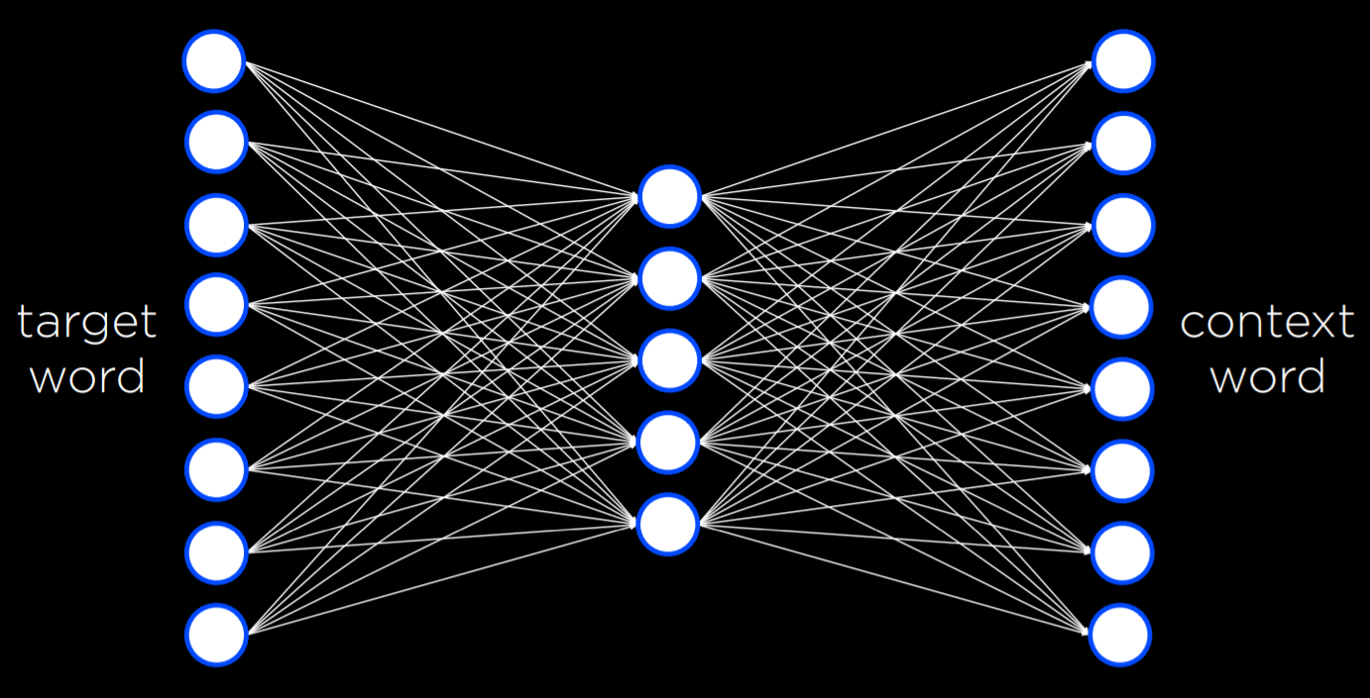

Questa rete neurale si rivela essere piuttosto potente. Alla fine del processo, ogni parola diventa semplicemente un vettore, ovvero una sequenza di numeri. Per esempio:

```
book: [-0.226776 -0.155999 -0.048995 -0.569774 0.053220 0.124401 -0.091108 -0.606255 -0.114630 0.473384 0.061061 0.551323 -0.245151 -0.014248 -0.210003 0.316162 0.340426 0.232053 0.386477 -0.025104 -0.024492 0.342590 0.205586 -0.554390 -0.037832 -0.212766 -0.048781 -0.088652 0.042722 0.000270 0.356324 0.212374 -0.188433 0.196112 -0.223294 -0.014591 0.067874 -0.448922 -0.290960 -0.036474 -0.148416 0.448422 0.016454 0.071613 -0.078306 0.035400 0.330418 0.293890 0.202701 0.555509 0.447660 -0.361554 -0.266283 -0.134947 0.105315 0.131263 0.548085 -0.195238 0.062958 -0.011117 -0.226676 0.050336 -0.295650 -0.201271 0.014450 0.026845 0.403077 -0.221277 -0.236224 0.213415 -0.163396 -0.218948 -0.242459 -0.346984 0.282615 0.014165 -0.342011 0.370489 -0.372362 0.102479 0.547047 0.020831 -0.202521 -0.180814 0.035923 -0.296322 -0.062603 0.232734 0.191323 0.251916 0.150993 -0.024009 0.129037 -0.033097 0.029713 0.125488 -0.018356 -0.226277 0.437586 0.004913]
```

Di per sé, questi numeri non significano molto. Ma trovando quali altre parole nel corpus hanno vettori più simili, possiamo eseguire una funzione che genera le parole più simili alla parola *book*. Nel caso di questa rete, saranno: book, books, essay, memoir, essays, novella, anthology, blurb, autobiography, audiobook.

Attraverso una serie di numeri che non hanno alcun significato specifico presi da soli, l’IA è in grado di generare parole molto simili a book, non in termini di lettere o suoni, ma di significato.

Possiamo anche calcolare la differenza tra parole basandoci su quanto i loro vettori siano diversi. Per esempio, la differenza tra king e man è simile alla differenza tra queen e woman. Cioè, se aggiungiamo la differenza tra king e man al vettore di woman, la parola più vicina al vettore risultante è queen.

Allo stesso modo, se aggiungiamo la differenza tra ramen e japan ad america, otteniamo burritos.

Usando reti neurali e rappresentazioni distribuite delle parole, portiamo la nostra IA a comprendere le somiglianze semantiche tra le parole nella lingua, avvicinandoci sempre di più a IA in grado di comprendere e produrre linguaggio umano.

# Neural Networks

Ricordiamo che una rete neurale prende un input, lo passa attraverso la rete e produce un output. Fornendo alla rete dati di addestramento, questa può migliorare sempre di più la precisione nel tradurre l’input in output. Comunemente, la traduzione automatica usa reti neurali.

Nella pratica, quando traduciamo parole, vogliamo tradurre una frase o un paragrafo. Siccome una frase ha una lunghezza variabile, ci troviamo davanti al problema di tradurre una sequenza in un’altra sequenza con dimensioni non fisse. Se hai mai conversato con un chatbot IA, sai che deve comprendere una sequenza di parole e generare una sequenza appropriata come output.

Le **Recurrent neural networks** (RNN) possono eseguire la rete neurale più volte, tenendo traccia di uno stato che conserva tutte le informazioni rilevanti. L’input viene fornito alla rete, creando uno stato nascosto. Passando un secondo input all’encoder, insieme al primo stato nascosto, produce un nuovo stato nascosto. Questo processo si ripete finché non viene passato un end token.

A questo punto inizia la fase di decodifica, creando stato nascosto dopo stato nascosto fino a ottenere la parola finale e un altro end token.

Tuttavia, sorgono alcuni problemi. Un problema si verifica nella fase di encoding, dove tutte le informazioni dell’input devono essere immagazzinate in un unico stato finale. Per sequenze molto lunghe, è molto difficile concentrare tutte queste informazioni in un solo valore di stato. Sarebbe utile in qualche modo combinare tutti gli stati nascosti.

Un altro problema è che alcuni stati nascosti nella sequenza di input sono più importanti di altri. Esiste un modo per capire quali stati (o parole) sono più importanti rispetto ad altri?


# Attention

**Attention** si riferisce alla capacità della rete neurale di decidere quali valori sono più importanti di altri. Nella frase “What is the capital of Massachusetts,” l’Attention permette alla rete neurale di scegliere a quali valori prestare attenzione in ogni fase della generazione della frase di output.

Eseguendo questo calcolo, la rete neurale mostrerà che, nel generare l’ultima parola della risposta, “capital” e “Massachusetts” sono le parole più importanti su cui concentrarsi.

Prendendo i punteggi di attenzione, moltiplicandoli per i valori degli stati nascosti generati dalla rete e sommando il tutto, la rete neurale crea un vettore di contesto finale che il decodificatore può usare per calcolare la parola finale.

Una sfida che si presenta in calcoli come questi è che le reti neurali ricorrenti richiedono un addestramento sequenziale parola dopo parola, che richiede molto tempo.

Con la crescita dei LLM (Large Language Models), il tempo di addestramento diventa sempre più lungo. Il desiderio di parallelismo è aumentato costantemente man mano che è necessario addestrare dataset sempre più grandi.

Per questo motivo, è stata introdotta una nuova architettura.

# Transformers

**Transformers** sono un nuovo tipo di architettura di addestramento in cui ogni parola di input viene passata attraverso una rete neurale simultaneamente. Una parola di input entra nella rete neurale ed è rappresentata come una rappresentazione codificata. Poiché tutte le parole vengono inserite nella rete neurale allo stesso tempo, l’ordine delle parole potrebbe facilmente perdersi. Per questo motivo, all’input viene aggiunta una **codifica di posizione**. La rete neurale quindi utilizza sia la parola sia la posizione della parola nella rappresentazione codificata.

Inoltre, viene aggiunto un passaggio di **self-attention** per aiutare a definire il contesto della parola in input. Infatti, le reti neurali spesso utilizzano più passaggi di self-attention per comprendere meglio il contesto. Questo processo viene ripetuto più volte per ciascuna parola nella sequenza.

Il risultato sono rappresentazioni codificate che saranno utili quando sarà il momento di decodificare l’informazione.

Nella fase di decodifica, la parola di output precedente e la sua codifica di posizione vengono date a più passaggi di self-attention e alla rete neurale. Inoltre, più passaggi di attenzione ricevono la rappresentazione codificata dal processo di codifica e la forniscono alla rete neurale.

Così, le parole possono prestare attenzione l’una all’altra. Inoltre, è possibile il processamento parallelo e i calcoli risultano veloci e precisi.